# Birth-Death Model

Experiment:
- birth–death,
- no adhesion,
- cell-driven birth only,
- a small sweep in $\gamma=r_{birth}/r_{death}$.
- ensemble averages,
- survival probability,
- mean population,
- mean density,
- long-time summaries to probe extinction vs active vs homeostatic behavior.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import (
    make_lattice,
    make_birth_kernel,
    ModelConfig,
    NoAdhesion,
    CultureSimulator,
)

from lib import (
    aggregate_results,
    plot_ensemble_curve,
)

## Global Parameters

In [2]:
# ----------------------------
# Global parameters
# ----------------------------
lattice_kind = "square"
update_source = "cell_driven"

r_birth = 1.0
gamma_values = [0.6, 0.8, 1.0, 1.25, 1.5, 2.0, 3.0, 5.0]

seed_radius = 5.0

t_final = 100.0
n_observations = 201
observation_times = np.linspace(0.0, t_final, n_observations)

n_runs = 30
base_seed = 20000

# Use a lattice large enough that boundary effects are not dominant too early
nrows = 201
ncols = 201

## Helper - one ensemble at fixed gamma

In [3]:
def run_birth_death_ensemble(
    gamma: float,
    lattice_kind: str = "square",
    update_source: str = "cell_driven",
    r_birth: float = 1.0,
    seed_radius: float = 5.0,
    t_final: float = 100.0,
    observation_times=None,
    n_runs: int = 30,
    base_seed: int = 0,
    nrows: int = 201,
    ncols: int = 201,
):
    r_death = r_birth / gamma

    lattice = make_lattice(kind=lattice_kind, nrows=nrows, ncols=ncols, periodic=False)
    simulator = CultureSimulator(lattice=lattice)
    initial_state = lattice.make_disk_state(radius=seed_radius)

    results = []

    for i in range(n_runs):
        config = ModelConfig(
            birth_kernel=make_birth_kernel(update_source),
            r_birth=r_birth,
            r_death=r_death,
            birth_modifier=NoAdhesion(),
            death_modifier=NoAdhesion(),
        )

        rng = np.random.default_rng(base_seed + i)

        result = simulator.run(
            initial_state=initial_state,
            config=config,
            t_final=t_final,
            rng=rng,
            observation_times=observation_times,
            store_snapshots=False,
        )

        results.append(result)

    agg = aggregate_results(results)
    return lattice, results, agg

## Run Sweep

In [4]:
sweep_results = {}
sweep_agg = {}

for j, gamma in enumerate(gamma_values):
    print(f"Running gamma = {gamma}")

    lattice, results, agg = run_birth_death_ensemble(
        gamma=gamma,
        lattice_kind=lattice_kind,
        update_source=update_source,
        r_birth=r_birth,
        seed_radius=seed_radius,
        t_final=t_final,
        observation_times=observation_times,
        n_runs=n_runs,
        base_seed=base_seed + 1000 * j,
        nrows=nrows,
        ncols=ncols,
    )

    sweep_results[gamma] = results
    sweep_agg[gamma] = agg

Running gamma = 0.6


/home/nate/Devel/lattice/src/lib.py:87: RuntimeWarning: Mean of empty slice
  "mean_radius": np.nanmean(rad, axis=0),
/home/nate/.virtualenvs/lattice/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/nate/Devel/lattice/src/lib.py:90: RuntimeWarning: Mean of empty slice
  "mean_roughness": np.nanmean(rough, axis=0),
/home/nate/Devel/lattice/src/lib.py:92: RuntimeWarning: Mean of empty slice
  "mean_front_velocity": np.nanmean(vel, axis=0),


Running gamma = 0.8
Running gamma = 1.0
Running gamma = 1.25
Running gamma = 1.5
Running gamma = 2.0
Running gamma = 3.0
Running gamma = 5.0


### Mean population evolution for sweep

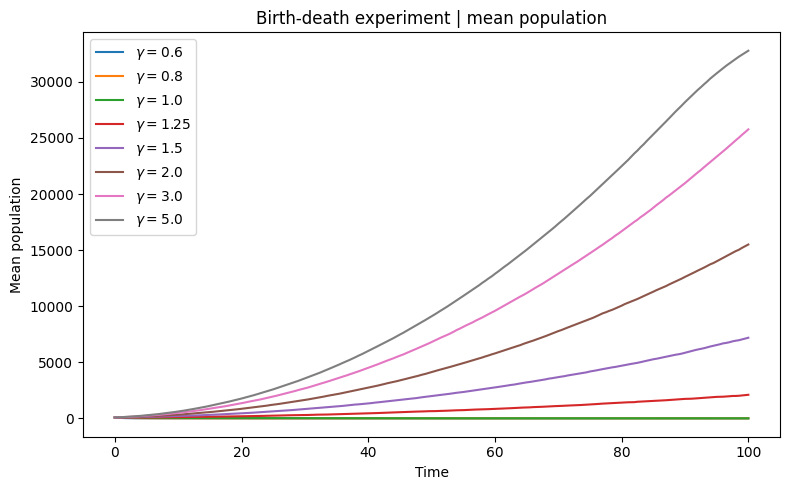

In [5]:
plt.figure(figsize=(8, 5))

for gamma in gamma_values:
    agg = sweep_agg[gamma]
    plt.plot(
        agg["time"],
        agg["mean_population"],
        label=fr"$\gamma={gamma}$",
    )

plt.xlabel("Time")
plt.ylabel("Mean population")
plt.title("Birth-death experiment | mean population")
plt.legend()
plt.tight_layout()
plt.show()

### Survival probability vs. time

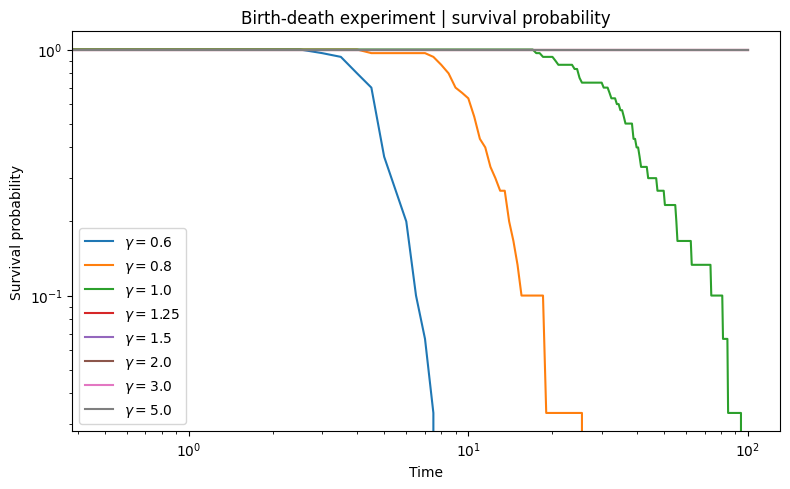

In [20]:
plt.figure(figsize=(8, 5))

for gamma in gamma_values:
    agg = sweep_agg[gamma]
    plt.plot(
        agg["time"],
        agg["survival_probability"],
        label=fr"$\gamma={gamma}$",
    )

plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.yscale("log")
plt.xscale("log")
plt.title("Birth-death experiment | survival probability")
plt.legend()
plt.tight_layout()
plt.show()

### Mean density vs. time

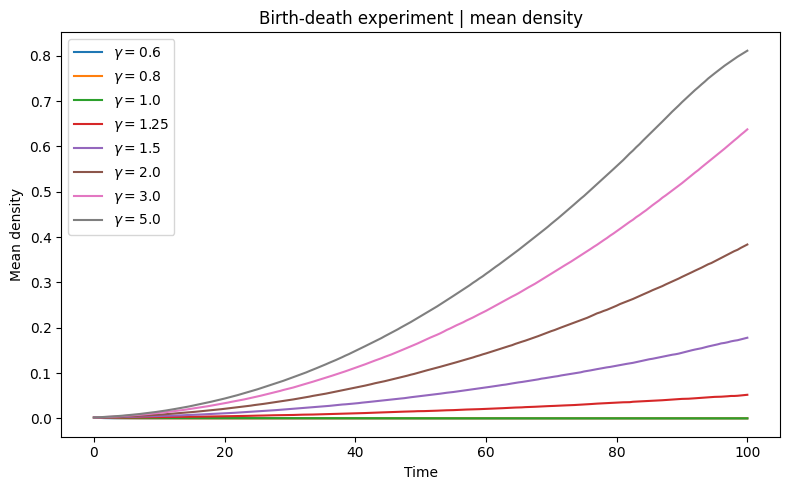

In [7]:
plt.figure(figsize=(8, 5))

for gamma in gamma_values:
    agg = sweep_agg[gamma]
    plt.plot(
        agg["time"],
        agg["mean_density"],
        label=fr"$\gamma={gamma}$",
    )

plt.xlabel("Time")
plt.ylabel("Mean density")
plt.title("Birth-death experiment | mean density")
plt.legend()
plt.tight_layout()
plt.show()

### Conditional mean population given survival

In [8]:
def conditional_mean_population(results):
    times = results[0].times
    pop = np.vstack([r.population for r in results])

    cond_mean = np.full(times.shape, np.nan, dtype=float)

    for j in range(pop.shape[1]):
        alive = pop[:, j] > 0
        if np.any(alive):
            cond_mean[j] = pop[alive, j].mean()

    return times, cond_mean

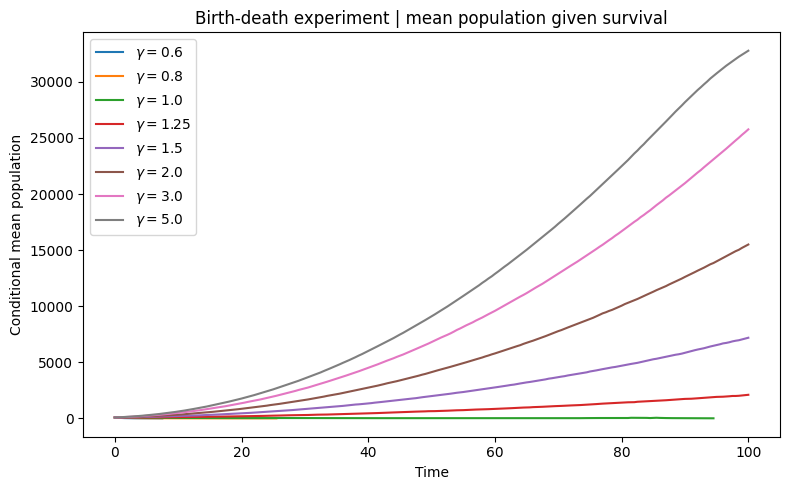

In [9]:
plt.figure(figsize=(8, 5))

for gamma in gamma_values:
    times, cond_mean = conditional_mean_population(sweep_results[gamma])
    plt.plot(times, cond_mean, label=fr"$\gamma={gamma}$")

plt.xlabel("Time")
plt.ylabel("Conditional mean population")
plt.title("Birth-death experiment | mean population given survival")
plt.legend()
plt.tight_layout()
plt.show()

### Long-time summary table

In [10]:
tail_fraction = 0.2  # last 20% of recorded times

summary_rows = []

for gamma in gamma_values:
    results = sweep_results[gamma]
    agg = sweep_agg[gamma]

    n_tail = max(2, int(len(agg) * tail_fraction))
    tail_df = agg.iloc[-n_tail:]

    final_survival = float(agg["survival_probability"].iloc[-1])
    final_mean_population = float(agg["mean_population"].iloc[-1])
    final_mean_density = float(agg["mean_density"].iloc[-1])

    tail_mean_population = float(tail_df["mean_population"].mean())
    tail_std_population = float(tail_df["mean_population"].std(ddof=0))

    tail_mean_density = float(tail_df["mean_density"].mean())
    tail_std_density = float(tail_df["mean_density"].std(ddof=0))

    summary_rows.append(
        {
            "gamma": gamma,
            "r_death": r_birth / gamma,
            "final_survival_probability": final_survival,
            "final_mean_population": final_mean_population,
            "final_mean_density": final_mean_density,
            "tail_mean_population": tail_mean_population,
            "tail_std_population": tail_std_population,
            "tail_mean_density": tail_mean_density,
            "tail_std_density": tail_std_density,
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df

,gamma,r_death,final_survival_probability,final_mean_population,final_mean_density,tail_mean_population,tail_std_population,tail_mean_density,tail_std_density
0,0.60,1.666667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.80,1.250000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1.00,1.000000,0.0,0.000000,0.000000,0.944167,1.146356,0.000023,0.000028
3,1.25,0.800000,1.0,2099.666667,0.051971,1737.975833,199.278225,0.043018,0.004933
4,1.50,0.666667,1.0,7186.933333,0.177890,5924.775833,728.838955,0.146649,0.018040
5,2.00,0.500000,1.0,15499.266667,0.383636,12732.760000,1578.852148,0.315160,0.039080
6,3.00,0.333333,1.0,25766.033333,0.637757,21185.030000,2628.250608,0.524369,0.065054
7,5.00,0.200000,1.0,32778.600000,0.811331,28124.268333,3048.596036,0.696128,0.075458


### Survival probability at final time vs. gamma

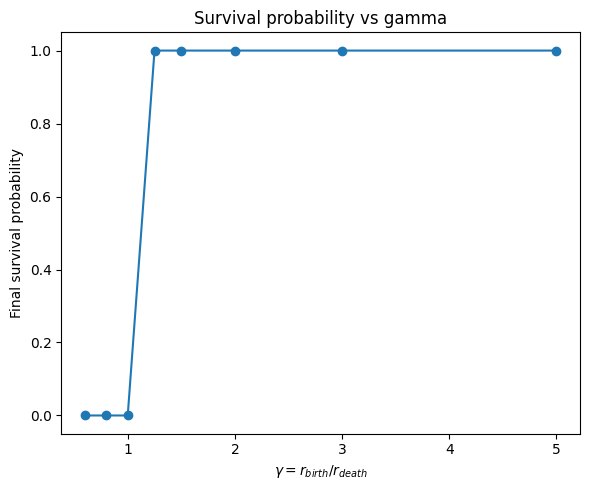

In [11]:
plt.figure(figsize=(6, 5))

plt.plot(
    summary_df["gamma"],
    summary_df["final_survival_probability"],
    "o-",
)

plt.xlabel(r"$\gamma = r_{birth}/r_{death}$")
plt.ylabel("Final survival probability")
plt.title("Survival probability vs gamma")
plt.tight_layout()
plt.show()

### Approximate stationary density vs. gamma

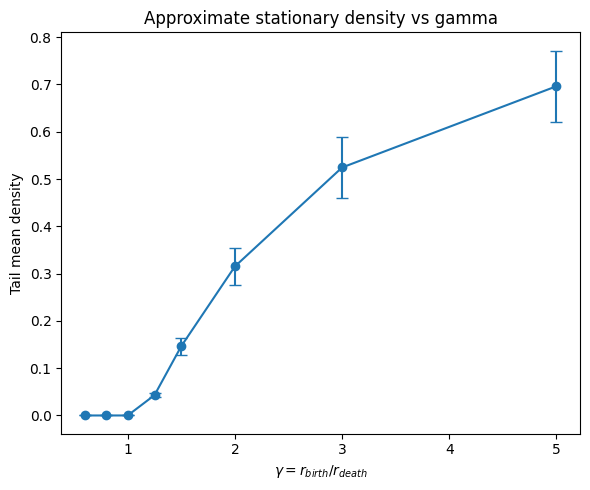

In [12]:
plt.figure(figsize=(6, 5))

plt.errorbar(
    summary_df["gamma"],
    summary_df["tail_mean_density"],
    yerr=summary_df["tail_std_density"],
    fmt="o-",
    capsize=4,
)

plt.xlabel(r"$\gamma = r_{birth}/r_{death}$")
plt.ylabel("Tail mean density")
plt.title("Approximate stationary density vs gamma")
plt.tight_layout()
plt.show()

### Approximate stationary population vs. gamma

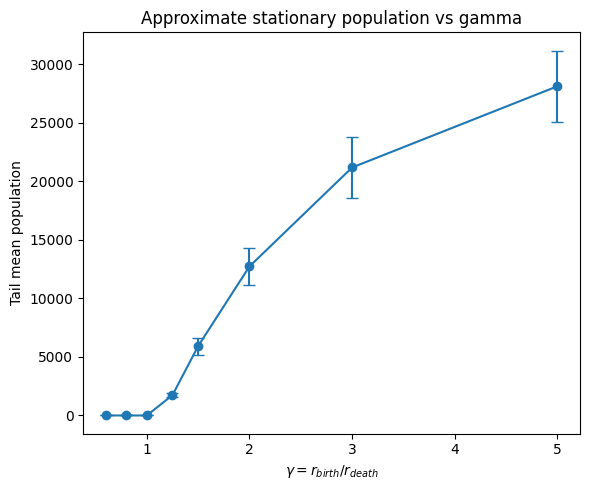

In [13]:
plt.figure(figsize=(6, 5))

plt.errorbar(
    summary_df["gamma"],
    summary_df["tail_mean_population"],
    yerr=summary_df["tail_std_population"],
    fmt="o-",
    capsize=4,
)

plt.xlabel(r"$\gamma = r_{birth}/r_{death}$")
plt.ylabel("Tail mean population")
plt.title("Approximate stationary population vs gamma")
plt.tight_layout()
plt.show()

### Crude Regime Classification

In [14]:
def classify_regime(row, survival_threshold=0.1, density_threshold=1e-3, rel_fluct_threshold=0.15):
    surv = row["final_survival_probability"]
    mean_d = row["tail_mean_density"]
    std_d = row["tail_std_density"]

    if surv < survival_threshold:
        return "extinction"

    if mean_d < density_threshold:
        return "near-extinct"

    rel_fluct = std_d / mean_d if mean_d > 0 else np.inf

    if rel_fluct < rel_fluct_threshold:
        return "homeostatic-like"

    return "active-growth-like"

In [15]:
summary_df["regime"] = summary_df.apply(classify_regime, axis=1)
summary_df

,gamma,r_death,final_survival_probability,final_mean_population,final_mean_density,tail_mean_population,tail_std_population,tail_mean_density,tail_std_density,regime
0,0.60,1.666667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,extinction
1,0.80,1.250000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,extinction
2,1.00,1.000000,0.0,0.000000,0.000000,0.944167,1.146356,0.000023,0.000028,extinction
3,1.25,0.800000,1.0,2099.666667,0.051971,1737.975833,199.278225,0.043018,0.004933,homeostatic-like
4,1.50,0.666667,1.0,7186.933333,0.177890,5924.775833,728.838955,0.146649,0.018040,homeostatic-like
5,2.00,0.500000,1.0,15499.266667,0.383636,12732.760000,1578.852148,0.315160,0.039080,homeostatic-like
6,3.00,0.333333,1.0,25766.033333,0.637757,21185.030000,2628.250608,0.524369,0.065054,homeostatic-like
7,5.00,0.200000,1.0,32778.600000,0.811331,28124.268333,3048.596036,0.696128,0.075458,homeostatic-like


### Inspecting one example trajectory for selected gamma values

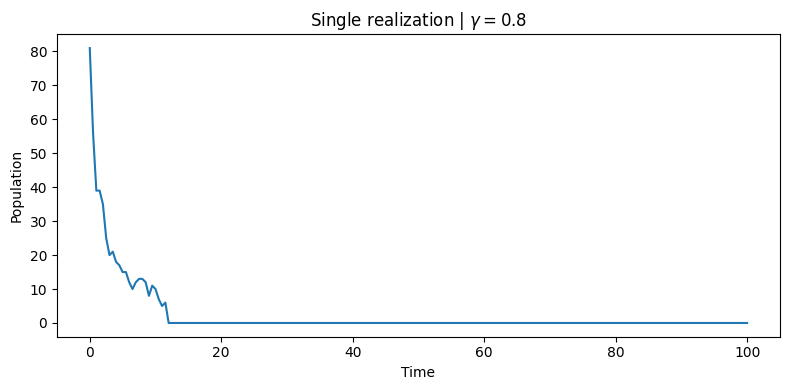

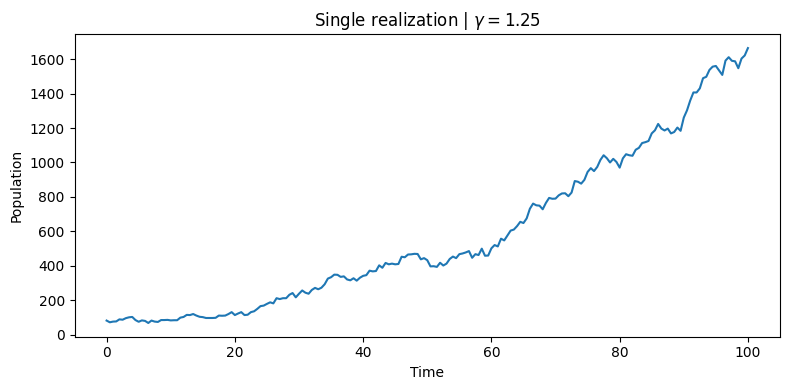

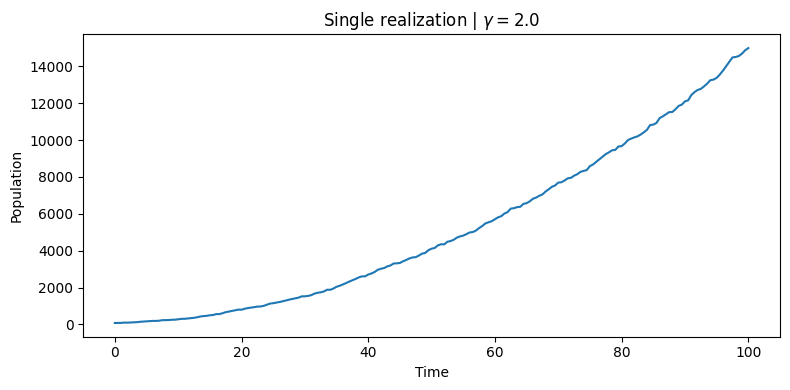

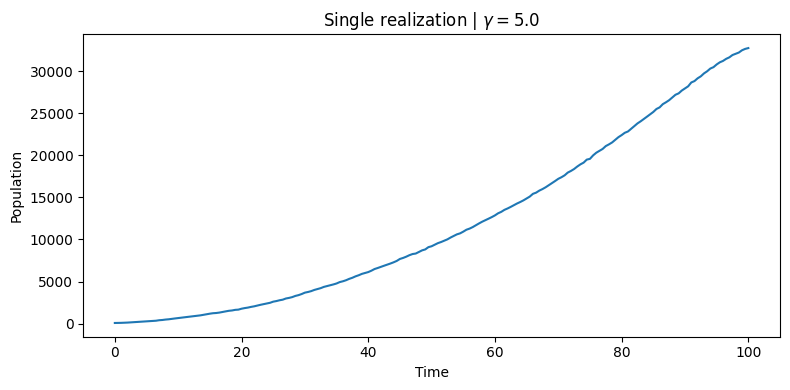

In [16]:
selected_gammas = [0.8, 1.25, 2.0, 5.0]

for gamma in selected_gammas:
    result = sweep_results[gamma][0]

    plt.figure(figsize=(8, 4))
    plt.plot(result.times, result.population, label="population")
    plt.xlabel("Time")
    plt.ylabel("Population")
    plt.title(fr"Single realization | $\gamma={gamma}$")
    plt.tight_layout()
    plt.show()

### Is the tail approximately stationary?

In [17]:
tail_slope_rows = []

for gamma in gamma_values:
    agg = sweep_agg[gamma]

    n_tail = max(2, int(len(agg) * tail_fraction))
    tail_df = agg.iloc[-n_tail:]

    t_tail = tail_df["time"].to_numpy()
    pop_tail = tail_df["mean_population"].to_numpy()
    dens_tail = tail_df["mean_density"].to_numpy()

    pop_slope, pop_intercept = np.polyfit(t_tail, pop_tail, deg=1)
    dens_slope, dens_intercept = np.polyfit(t_tail, dens_tail, deg=1)

    tail_slope_rows.append(
        {
            "gamma": gamma,
            "tail_population_slope": pop_slope,
            "tail_density_slope": dens_slope,
        }
    )

tail_slope_df = pd.DataFrame(tail_slope_rows)
tail_slope_df

,gamma,tail_population_slope,tail_density_slope
0,0.60,0.000000,0.000000
1,0.80,0.000000,0.000000
2,1.00,-0.176892,-0.000004
3,1.25,34.488311,0.000854
4,1.50,126.198918,0.003124
5,2.00,273.399500,0.006767
6,3.00,455.197736,0.011267
7,5.00,527.235360,0.013050


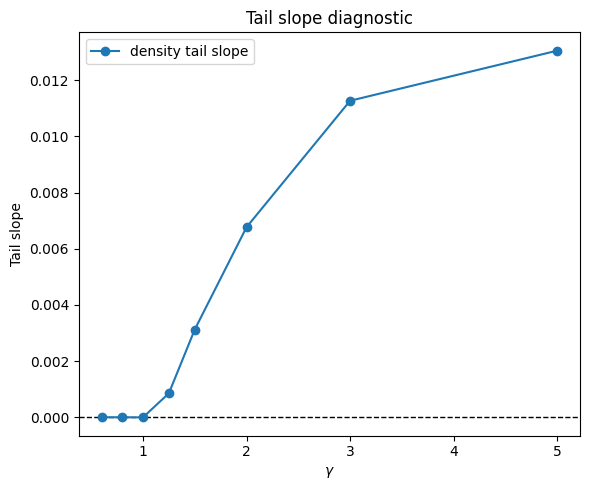

In [18]:
plt.figure(figsize=(6, 5))
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)

plt.plot(
    tail_slope_df["gamma"],
    tail_slope_df["tail_density_slope"],
    "o-",
    label="density tail slope",
)

plt.xlabel(r"$\gamma$")
plt.ylabel("Tail slope")
plt.title("Tail slope diagnostic")
plt.legend()
plt.tight_layout()
plt.show()

If the tail slope is close to zero while survival remains high and density stays bounded away from zero, that is evidence for a homeostatic-like regime.